In [65]:
# Import libries
import numpy as np
import pandas as pd
import os
import re
import glob
import json
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyranges as pr
import pysam
from matplotlib.patches import Patch

# from scipy.stats import mannwhitneyu, stats
# from statannotations.Annotator import Annotator

current_directory = os.getcwd()
print("Current Directory:", current_directory)
pd.set_option("display.max_columns", None)


Current Directory: /mnt/NAS3/home/jiwon/ECTRES/python


In [66]:
def classify_sample(row):
    if row['amplicon_decomposition_class'] == 'No amp/Invalid':
        return 'NoAmp'
    elif row['ecDNA+'] == 'Positive':
        return 'ecDNA'
    else:
        return 'ChrAmp'
        
    
def classify_amplicon(row):
    if row["ecDNA+"] == "Positive":
        return "ecDNA"
    if row["BFB+"] == "Positive":
        return "BFB"
    
    amp_class = row["amplicon_decomposition_class"]
    if amp_class == "Linear":
        return "Linear"
    if amp_class == "Complex-non-cyclic":
        return "Complex-non-cyclic"
    if amp_class == "No amp/Invalid":
        return "none"
    
    return "unknown"

## Manifest & sample barcoding

In [67]:
manifest=pd.read_csv('../manifest/ECTRES_clones_nf_dna_fastqs_20260303.csv')
manifest.head(2)

# manifest['aliquot_barcode'].nunique()

,aliquot_barcode,source_barcode,sample_barcode,patient_barcode,sample_type,tumor_or_normal,sequence_type,sample_legacy_id,gender,RGID,RGPL,RGPU,RGLB,RGDT,RGCN,FQ1,FQ2,action
0,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,ECGI1,ECTRES-ECGI1-0001-TPX-A01,ECTRES-ECGI1-0001,TP,tumor,WGS,EG_1,XY,2333V.6,ILLUMINA,2333VCLT4.6,ZKDN250032992,NaN,CBM,/mnt/NAS3/home/mary/rawData/ECTRES/X209SC25116...,/mnt/NAS3/home/mary/rawData/ECTRES/X209SC25116...,NaN
1,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,ECGI1,ECTRES-ECGI1-0001-TPX-A01,ECTRES-ECGI1-0001,TP,tumor,WGS,EG_1,XY,232NW.1,ILLUMINA,232NW2LT3.1,ZKDN250032992,NaN,CBM,/mnt/NAS3/home/mary/rawData/ECTRES/X209SC25116...,/mnt/NAS3/home/mary/rawData/ECTRES/X209SC25116...,NaN


In [68]:
manifest["sample_id"] = manifest["sample_legacy_id"].fillna("parental")
sample_mapping = manifest[['aliquot_barcode','source_barcode','sample_barcode','patient_barcode','sample_id']].drop_duplicates()

print(manifest.shape, sample_mapping.shape)

(87, 19) (77, 5)


In [69]:
sample_mapping.groupby('source_barcode').size()

source_barcode
ECGI1    34
EFM19    11
H2170    32
dtype: int64

In [70]:
sample_mapping.head()
sample_mapping[sample_mapping['sample_id']=='parental']

,aliquot_barcode,source_barcode,sample_barcode,patient_barcode,sample_id
60,ECTRES-H2170-0001-TPX-A01-WGS-3YV111,H2170,ECTRES-H2170-0001-TPX-A01,ECTRES-H2170-0001,parental
61,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,ECGI1,ECTRES-ECGI1-0001-TPX-A01,ECTRES-ECGI1-0001,parental
62,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,EFM19,ECTRES-EFM19-0001-TPX-A01,ECTRES-EFM19-0001,parental


## Amplicon Architect

In [98]:
base_dir = '../summary/aaSuite_germline_ms/10X'
!ls ../summary/aaSuite_germline_ms/10X/ 


ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_annotated_cycles_files.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_aa_amplicons.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_amplicon_classification_profiles.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_ecDNA_counts.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_feature_basic_properties.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_feature_entropy.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_gene_list.csv
log_20260313.txt


In [99]:
aa_classification=pd.read_csv(f'{base_dir}/ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_amplicon_classification_profiles.csv')

print(aa_classification.shape)
aa_classification.head(2)

(2425, 8)


,amplicon_barcode,aa_barcode,sample_name,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon10,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon10,No amp/Invalid,None detected,None detected,0
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon11,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon11,Linear,None detected,None detected,0


In [100]:
aa_classification.describe(include='object')

,amplicon_barcode,aa_barcode,sample_name,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+
count,2425,2425,2425,2425,2425,2425,2425
unique,2425,77,77,47,4,2,2
top,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon10,ECTRES-ECGI1-0001-TPX-A27-WGS-4SF851,ECTRES-ECGI1-0001-TPX-A27-WGS-4SF851,amplicon7,No amp/Invalid,None detected,None detected
freq,1,47,47,77,1444,2370,2341


In [101]:
aa_amplicons=pd.read_csv(f'{base_dir}/ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_aa_amplicons.csv')

print(aa_amplicons.shape)
# aa_amplicons.head()

(2425, 18)


In [102]:
aaSuite_gemline_ms_merge = pd.merge(aa_classification, aa_amplicons, how='inner', on=['amplicon_barcode', 'aa_barcode'])
aaSuite_gemline_ms_merge.shape

(2425, 24)

In [103]:
aaSuite_gemline_ms_merge['amplicon_decomposition_class'].unique()

array(['No amp/Invalid', 'Linear', 'Cyclic', 'Complex-non-cyclic'],
      dtype=object)

In [104]:
sample_mapping.columns

Index(['aliquot_barcode', 'source_barcode', 'sample_barcode',
       'patient_barcode', 'sample_id', 'aa_barcode'],
      dtype='object')

In [105]:
sample_mapping['aa_barcode'] = sample_mapping['aliquot_barcode']
aaSuite_gemline_ms = pd.merge(aaSuite_gemline_ms_merge, sample_mapping[['aa_barcode','source_barcode','sample_id']], how='left', on=['aa_barcode'])
aaSuite_gemline_ms = aaSuite_gemline_ms.drop(columns=["sample_name"])
aaSuite_gemline_ms['amplicon_type'] = aaSuite_gemline_ms.apply(classify_amplicon, axis=1)
aaSuite_gemline_ms.head(2)

,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,amplicon_type
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon10,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon10,No amp/Invalid,None detected,None detected,0,10,amplicon10,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,15:20824661-20979641,",",154981,154980,2.750840,1,1,0,0,0,0,0,EFM19,EFM_5,none
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon11,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon11,Linear,None detected,None detected,0,11,amplicon11,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,16:33268118-33533123,",",265006,265003,3.730855,1,3,0,2,0,0,2,EFM19,EFM_5,Linear


In [130]:

# aaSuite_gemline_ms_1x = aaSuite_gemline_ms.copy()
# aaSuite_gemline_ms_nox = aaSuite_gemline_ms.copy()
# aaSuite_gemline_ms_10x = aaSuite_gemline_ms.copy()


aaSuite_gemline_ms_nox['source_barcode'].unique()
aaSuite_gemline_ms_nox['amplicon_type'].unique()

# array(['EFM19', 'H2170', 'ECGI1'], dtype=object)
# 

array(['none', 'Complex-non-cyclic', 'ecDNA', 'Linear', 'BFB'],
      dtype=object)

In [188]:
# aaSuite_gemline_ms_10x.to_csv('../summary/aaSuite_germline_ms/10X/aaSuite_gemline_ms_all.csv',index=False)


In [210]:
df = aaSuite_gemline_ms_10x.copy()
celline = 'EFM19'
print(df[(df['sample_id']=='parental')&(df['source_barcode']==celline)]['amplicon_type'].value_counts())


df[(df['sample_id']=='parental')&(df['source_barcode']==celline)&(df['amplicon_type']=='ecDNA')]['OncogenesAmplified'].tolist()

amplicon_type
Linear                4
none                  3
ecDNA                 1
Complex-non-cyclic    1
Name: count, dtype: int64


['SMARCE1,RAB22A,LAPTM4B,EXT1,TNS4,E2F5,CTSZ,NOV,HEY1,PVT1,CDC6,CDH17,SLC12A5,RUNX1T1,CLTC,TPD52,SNAI1,MTDH,IGF2BP1,SALL4,EIF3E,AURKA,BMP7,ARID2,MAP2K4,SPAG9,RPL23,NCOA3,GNAS,GAS7,HLF,RAD21,SREBF1,C17orf37,COL1A1,INTS8,MSI2,LASP1,MLLT6,NME1,PPM1D,ZNF217,NDRG1,MYC,ITGA3,ERBB2,COPS3,RARA,THRA,UBE2C,CDK12,CYP24A1,TRIB1,CSF3,WISP1,NCRNA00275,']

In [211]:
df[(df['sample_id']=='parental')&(df['source_barcode']==celline)&df['OncogenesAmplified'].str.contains(r'\bERBB2\b', na=False)]



,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,amplicon_type
2417,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977-amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,amplicon2,Cyclic,Positive,None detected,4,2,amplicon2,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,25,"1:51779188-51790039,1:57048384-57838394,8:7026...","SMARCE1,RAB22A,LAPTM4B,EXT1,TNS4,E2F5,CTSZ,NOV...",97029169,70179117,11.688538,6,498,182,153,33,24,87,EFM19,parental,ecDNA


In [209]:
df[(df['sample_id']=='parental')&(df['source_barcode']==celline)&df['OncogenesAmplified'].str.contains(r'\bERBB2\b', na=False)]['Intervals'].tolist()


['3:111173429-111384740,8:102090543-102301854,8:127916498-130061502,14:22159983-26689961,17:37630838-38570838']

In [183]:
df['amplicon_type'].unique()

array(['none', 'Complex-non-cyclic', 'ecDNA', 'Linear', 'BFB'],
      dtype=object)

In [184]:
df.head(2)

,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,amplicon_type
0,ECTRES-H2170-0001-TPX-A04-WGS-7PU017-amplicon10,ECTRES-H2170-0001-TPX-A04-WGS-7PU017,amplicon10,No amp/Invalid,None detected,None detected,0,10,amplicon10,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,7:3432367-3512366,",",80000,0,2.0,1,1,0,0,0,0,0,H2170,NCI_4,none
1,ECTRES-H2170-0001-TPX-A04-WGS-7PU017-amplicon11,ECTRES-H2170-0001-TPX-A04-WGS-7PU017,amplicon11,No amp/Invalid,None detected,None detected,0,11,amplicon11,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,8:13426936-14301994,",",875059,0,2.0,1,1,0,0,0,0,0,H2170,NCI_4,none


In [185]:
df2 = df.copy()

# 타입 이름 단순화
df2['amplicon_type_simple'] = df2['amplicon_type'].replace({
    'Complex-non-cyclic': 'CNC'
})

# sample별 전체 amplicon 수
summary = (
    df2.groupby(['source_barcode', 'sample_id'])
    .agg(n_total_amplicons=('amplicon_number', 'nunique'))
    .reset_index()
)

# sample별 타입별 amplicon 수
type_summary = (
    df2.groupby(['source_barcode', 'sample_id', 'amplicon_type_simple'])['amplicon_number']
    .nunique()
    .unstack(fill_value=0)
    .reset_index()
)

# merge
summary = summary.merge(type_summary, on=['source_barcode', 'sample_id'], how='left').fillna(0)

# 필요한 컬럼 없으면 생성
for col in ['none', 'Linear', 'ecDNA', 'CNC', 'BFB']:
    if col not in summary.columns:
        summary[col] = 0

# 정수형 변환
count_cols = ['n_total_amplicons', 'none', 'Linear', 'ecDNA', 'CNC', 'BFB']
summary[count_cols] = summary[count_cols].astype(int)

# 정렬
summary = summary.sort_values(['source_barcode', 'sample_id']).reset_index(drop=True)

summary

,source_barcode,sample_id,n_total_amplicons,BFB,CNC,Linear,ecDNA,none
0,ECGI1,EG_1,46,2,0,20,0,24
1,ECGI1,EG_10,46,0,0,26,0,20
2,ECGI1,EG_11,42,0,0,23,0,19
3,ECGI1,EG_12,43,1,0,20,0,22
4,ECGI1,EG_13,44,1,0,24,0,19
...,...,...,...,...,...,...,...,...
72,H2170,NCI_6,24,1,0,1,1,21
73,H2170,NCI_7,24,1,0,1,1,21
74,H2170,NCI_8,24,1,0,2,2,19
75,H2170,NCI_9,24,1,0,1,2,20


In [186]:
# summary 테이블이 이미 있다고 가정
summary['has_ecDNA'] = summary['ecDNA'] >= 1
summary['has_BFB'] = summary['BFB'] >= 1
summary['has_CNC'] = summary['CNC'] >= 1

# 전체 unique sample 중 ecDNA 포함 sample 수
n_has_ecdna = summary['has_ecDNA'].sum()
print("ecDNA가 하나라도 있는 unique sample 수:", n_has_ecdna)

# source_barcode별
summary.groupby('source_barcode')['has_ecDNA'].sum().reset_index(name='n_samples_with_ecDNA')

ecDNA가 하나라도 있는 unique sample 수: 43


,source_barcode,n_samples_with_ecDNA
0,ECGI1,3
1,EFM19,9
2,H2170,31


In [187]:
summary_clone = summary[~summary['sample_id'].str.contains('parental', case=False, na=False)].copy()

summary_clone['has_ecDNA'] = summary_clone['ecDNA'] >= 1

n_has_ecdna = summary_clone['has_ecDNA'].sum()
print("ecDNA가 하나라도 있는 unique clone 수 (parental 제외):", n_has_ecdna)

summary_clone.groupby('source_barcode')['has_ecDNA'].sum().reset_index(name='n_clones_with_ecDNA')

ecDNA가 하나라도 있는 unique clone 수 (parental 제외): 40


,source_barcode,n_clones_with_ecDNA
0,ECGI1,2
1,EFM19,8
2,H2170,30


In [148]:
aaSuite_gemline_ms_ECGI=aaSuite_gemline_ms[(aaSuite_gemline_ms['source_barcode']=='ECGI1')&(aaSuite_gemline_ms['sample_id']!='EG_21')]
aaSuite_gemline_ms_ECGI.shape

(1487, 26)

In [27]:
# aaSuite_gemline_ms_ECGI.to_csv('../summary/aaSuite_germline_ms/1X/aaSuite_gemline_ms_ECGI.csv',index=False)


In [28]:
aaSuite_gemline_ms_ECGI.head(2)

,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,amplicon_type
157,ECTRES-ECGI1-0001-TPX-A02-WGS-5KM079-amplicon10,ECTRES-ECGI1-0001-TPX-A02-WGS-5KM079,amplicon10,No amp/Invalid,None detected,None detected,0,10,amplicon10,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,5:680025-2945112,"TERT,",2265088,2256972,4.654083,1,4,0,3,0,0,3,ECGI1,EG_2,none
158,ECTRES-ECGI1-0001-TPX-A02-WGS-5KM079-amplicon11,ECTRES-ECGI1-0001-TPX-A02-WGS-5KM079,amplicon11,No amp/Invalid,None detected,None detected,0,11,amplicon11,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,5:56760725-56995730,",",235006,235005,3.775656,1,1,0,0,0,0,0,ECGI1,EG_2,none


In [29]:
aaSuite_gemline_ms_ECGI[aaSuite_gemline_ms_ECGI['OncogenesAmplified'].str.contains(r'\bERBB2\b', na=False)]


,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,amplicon_type
188,ECTRES-ECGI1-0001-TPX-A02-WGS-5KM079-amplicon39,ECTRES-ECGI1-0001-TPX-A02-WGS-5KM079,amplicon39,Linear,None detected,None detected,0,39,amplicon39,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,17:37530838-38470838,"CSF3,ERBB2,CDC6,RARA,CDK12,THRA,C17orf37,",940001,462960,5.970390,1,3,0,2,0,0,2,ECGI1,EG_2,Linear
244,ECTRES-ECGI1-0001-TPX-A06-WGS-6MJ692-amplicon7,ECTRES-ECGI1-0001-TPX-A06-WGS-6MJ692,amplicon7,Cyclic,None detected,Positive,0,7,amplicon7,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,2,"2:102320290-104350065,17:37630838-38470838","CDK12,RARA,ERBB2,CDC6,CSF3,THRA,C17orf37,",2869777,2392427,13.773533,2,12,3,5,1,3,4,ECGI1,EG_6,BFB
278,ECTRES-ECGI1-0001-TPX-A19-WGS-2FI919-amplicon39,ECTRES-ECGI1-0001-TPX-A19-WGS-2FI919,amplicon39,Linear,None detected,None detected,0,39,amplicon39,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,17:37530838-38470838,"THRA,C17orf37,CDC6,CDK12,ERBB2,CSF3,RARA,",940001,374099,6.327704,1,3,0,2,0,0,2,ECGI1,EG_19,Linear
323,ECTRES-ECGI1-0001-TPX-A31-WGS-8UC862-amplicon38,ECTRES-ECGI1-0001-TPX-A31-WGS-8UC862,amplicon38,Linear,None detected,None detected,0,38,amplicon38,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,17:37630838-38470838,"THRA,CDK12,CDC6,RARA,C17orf37,CSF3,ERBB2,",840001,356361,6.664419,1,2,0,1,0,0,1,ECGI1,EG_31,Linear
405,ECTRES-ECGI1-0001-TPX-A29-WGS-1IJ826-amplicon39,ECTRES-ECGI1-0001-TPX-A29-WGS-1IJ826,amplicon39,Linear,None detected,None detected,0,39,amplicon39,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,17:37630838-38470838,"THRA,CDC6,C17orf37,RARA,ERBB2,CDK12,CSF3,",840001,839999,3.646615,1,2,0,1,0,0,1,ECGI1,EG_29,Linear
518,ECTRES-ECGI1-0001-TPX-A28-WGS-1QA676-amplicon37,ECTRES-ECGI1-0001-TPX-A28-WGS-1QA676,amplicon37,Linear,None detected,None detected,0,37,amplicon37,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,17:37630838-38470838,"C17orf37,CSF3,CDC6,RARA,ERBB2,CDK12,THRA,",840001,362961,6.307120,1,2,0,1,0,0,1,ECGI1,EG_28,Linear
563,ECTRES-ECGI1-0001-TPX-A22-WGS-2EW406-amplicon38,ECTRES-ECGI1-0001-TPX-A22-WGS-2EW406,amplicon38,Linear,None detected,None detected,0,38,amplicon38,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,17:37530838-38470838,"CSF3,THRA,ERBB2,RARA,C17orf37,CDK12,CDC6,",940001,452160,5.919310,1,3,0,2,0,0,2,ECGI1,EG_22,Linear
633,ECTRES-ECGI1-0001-TPX-A14-WGS-7LI670-amplicon39,ECTRES-ECGI1-0001-TPX-A14-WGS-7LI670,amplicon39,No amp/Invalid,None detected,None detected,0,39,amplicon39,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,17:37630838-38470838,"THRA,C17orf37,RARA,CDK12,ERBB2,CSF3,CDC6,",840001,374961,3.501152,1,2,0,1,0,0,1,ECGI1,EG_14,none
692,ECTRES-ECGI1-0001-TPX-A26-WGS-6JQ388-amplicon39,ECTRES-ECGI1-0001-TPX-A26-WGS-6JQ388,amplicon39,Linear,None detected,None detected,0,39,amplicon39,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,17:37630838-38470838,"CSF3,ERBB2,RARA,CDK12,THRA,CDC6,C17orf37,",840001,356061,7.013913,1,2,0,1,0,0,1,ECGI1,EG_26,Linear
736,ECTRES-ECGI1-0001-TPX-A33-WGS-8HI613-amplicon38,ECTRES-ECGI1-0001-TPX-A33-WGS-8HI613,amplicon38,Linear,None detected,None detected,0,38,amplicon38,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,17:37530838-38470838,"ERBB2,RARA,CSF3,CDC6,C17orf37,CDK12,THRA,",940001,453960,5.122769,1,3,0,2,0,0,2,ECGI1,EG_33,Linear


In [22]:
# aaSuite_gemline_ms_ECGI[aaSuite_gemline_ms_ECGI['amplicon_type']=='ecDNA']

In [21]:
aaSuite_gemline_ms_ECGI["amplicon_type"].value_counts()

amplicon_type
Linear                749
none                  740
BFB                    40
Complex-non-cyclic      6
ecDNA                   4
Name: count, dtype: int64

In [22]:
aaSuite_gemline_ms_ECGI[["ecDNA+", "BFB+", "amplicon_decomposition_class"]].drop_duplicates()
# ecDNA+	BFB+	amplicon_decomposition_class

# None detected	None detected	No amp/Invalid -> none
# None detected	None detected	Linear amplification -> Linear amplification
# None detected	Positive	Cyclic -> BFB
# None detected	Positive	Complex non-cyclic -> BFB
# None detected	None detected	Complex non-cyclic -> Complex non-cyclic
# Positive	None detected	Cyclic -> ecDNA
# None detected	Positive	Linear amplification -> BFB


,ecDNA+,BFB+,amplicon_decomposition_class
157,None detected,None detected,No amp/Invalid
159,None detected,None detected,Linear
182,None detected,Positive,Complex-non-cyclic
223,None detected,None detected,Complex-non-cyclic
244,None detected,Positive,Cyclic
463,Positive,None detected,Cyclic
1695,None detected,Positive,Linear


In [23]:
df=aaSuite_gemline_ms_ECGI.copy()


df=df[df['sample_id']!='EG_21']
df.groupby(["sample_id", "amplicon_type"]).size().reset_index(name="count")

,sample_id,amplicon_type,count
0,EG_1,BFB,1
1,EG_1,Linear,20
2,EG_1,none,25
3,EG_10,Linear,26
4,EG_10,none,20
...,...,...,...
97,EG_9,ecDNA,1
98,EG_9,none,24
99,parental,BFB,1
100,parental,Linear,30


In [24]:
table = (
    df.groupby(["sample_id", "amplicon_type"])
      .size()
      .unstack(fill_value=0)
)
# table

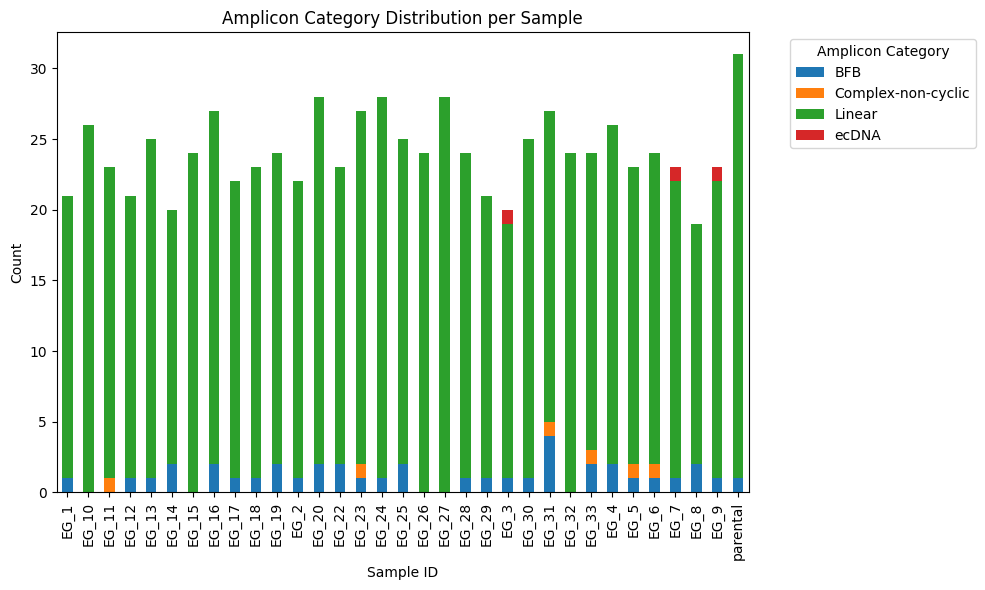

In [25]:
# table.plot(
#     kind="bar",
#     stacked=True,
#     figsize=(10,6)
# )

table_no_none = table.drop(columns=["none"], errors="ignore")
table_no_none.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.ylabel("Count")
plt.xlabel("Sample ID")
plt.title("Amplicon Category Distribution per Sample")
plt.legend(title="Amplicon Category", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [30]:
# df[df['amplicon_type']=='ecDNA']

In [127]:
# A. Parental Structure-calss retention: same clasee, switched class, not detected
# B. parental interval retention: yes, partial, no
# C. parental oncogene retention: retained, lost, uncertain
